# Eksperyment ewolucji VNP

Notebook do przeprowadzania wieloetapowej ewolucji automatow Von Neumann Probes.
Kazdy etap uruchamia symulacje, zbiera statystyki i wybiera najlepsze automaty do nastepnej generacji.

### Importy

In [46]:
import sys
import os
import json
import random
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
import threading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dodaj sciezke do src
project_root = Path(os.getcwd()).parent.parent
sys.path.insert(0, str(project_root / 'src'))

from Simulation import simulate, load_programs_from_folder, get_default_genome, parse_genome_from_program
from config import ResourceType

print(f"Projekt: {project_root}")
print("Importy zakonczone pomyslnie.")

Projekt: /home/julczyk/Dokumenty/Automaty/VNP
Importy zakonczone pomyslnie.


### Parametry eksperymentu

In [47]:
# === PARAMETRY OGOLNE ===
EXPERIMENT_NAME = f"evolution_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
RESULTS_DIR = Path("results-test") / EXPERIMENT_NAME

# === PARAMETRY EWOLUCJI ===
STAGES = 20                    # Ilosc etapow (generacji)
TO_NEXT = 15                   # Ilosc automatow przechodzacych do nastepnego etapu
EVAL_COUNT = 10                # Ilosc automatow w ewaluacji (eval < to_next)

# === PARAMETRY SYMULACJI ETAPU ===
STAGE_PARAMS = {
    'time': 300,              # Czas trwania etapu (ticki)
    'size': [120, 120],         # Rozmiar swiata
    'mutation_speed': 0.03,    # Wspolczynnik mutacji
    'mutation_type': 'all',   # Typ mutacji
    'seed': 200,               # Seed (bedzie zwiekszany dla kazdego etapu)
    'visualize': False,
    'logging_enabled': False,
    'make_timelapse': False,
    'export_frames': [1, 50, 150, 300],  # Klatki do eksportu
}


# === PARAMETRY SYMULACJI ETAPU ===
# STAGE_PARAMS = {
#     'time': 400,              # Czas trwania etapu (ticki)
#     'size': [150, 150],         # Rozmiar swiata
#     'mutation_speed': 0.03,    # Wspolczynnik mutacji
#     'mutation_type': 'all',   # Typ mutacji
#     'seed': 42,               # Seed (bedzie zwiekszany dla kazdego etapu)
#     'visualize': False,
#     'logging_enabled': False,
#     'make_timelapse': False,
#     'export_frames': [0, 100, 250, 500],  # Klatki do eksportu
# }


# === PARAMETRY EWALUACJI ===
EVAL_PARAMS = {
    'time': 100,              # Krotki czas ewaluacji
    'size': [60, 60],         # Mniejsza mapa
    'mutation_speed': 0,      # Brak mutacji
    'mutation_type': 'disabled',
    'visualize': False,
    'logging_enabled': False,
    'make_timelapse': False,
    'export_frames': [100],
}

# === WCZYTAJ PROGRAMY Z start_programs ===
START_PROGRAMS_DIR = Path("start_programs_base")

if START_PROGRAMS_DIR.exists():
    programs = load_programs_from_folder(str(START_PROGRAMS_DIR))
    INITIAL_POPULATION = [
        {'program': p['program'], 'genome': p.get('genome', get_default_genome())}
        for p in programs
        for _ in range(2)  # 2 automata per program
    ]
    print(f"Wczytano {len(programs)} programow z {START_PROGRAMS_DIR}:")
    for p in programs:
        print(f"  - {p['filename']}")
else:
    # Fallback - domyslny program
    INITIAL_PROGRAM = '''$PARTS:
1.0, 1.0, 1.5, 1.0, 0.5, 0.5, 1.0;

$PROGRAMM
{
    f_2(1.0, 1.0);
    IF (1.5 - X[3]) {
        f_7(1.0);
    }
    IF (X[3] - 1.5) {
        f_1(X[2], 1.0);
    }
    IF (0.0 - X[3]) {
        X[10] = X[10] + 1.0;
        IF (X[10] - 3.5) {
            X[10] = 0.0;
        }
        f_1(X[10], 1.0);
    }
    REDO;
}
'''
    INITIAL_POPULATION = [{'program': INITIAL_PROGRAM}] * 3
    print("Uzyto domyslnego programu (brak start_programs/)")

print(f"\nEksperyment: {EXPERIMENT_NAME}")
print(f"Etapy: {STAGES}, Do nastepnego: {TO_NEXT}, Ewaluacja: {EVAL_COUNT}")
print(f"Populacja startowa: {len(INITIAL_POPULATION)} automatow")
print(f"Czas etapu: {STAGE_PARAMS['time']} tickow, Czas ewaluacji: {EVAL_PARAMS['time']} tickow")

Wczytano 7 programow z start_programs_base:
  - basic_gatherer.srl
  - safe.srl
  - simple.srl
  - smart_gatherer.srl
  - standard.srl
  - static.srl
  - traveler.srl

Eksperyment: evolution_20260219_015542
Etapy: 20, Do nastepnego: 15, Ewaluacja: 10
Populacja startowa: 14 automatow
Czas etapu: 300 tickow, Czas ewaluacji: 100 tickow


### Funkcje pomocnicze

In [48]:
def calculate_stage_stats(df: pd.DataFrame) -> dict:
    """
    Oblicza dodatkowe statystyki z DataFrame etapu.
    """
    if len(df) == 0:
        return {
            'total_automata': 0, 'alive_at_end': 0, 'avg_age': 0,
            'sum_age': 0, 'avg_distance': 0, 'sum_distance': 0,
            'avg_offspring': 0, 'sum_offspring': 0,
            'avg_energy_produced': 0, 'avg_energy_consumed': 0,
            'resources': {}
        }
    
    resource_cols = [col for col in df.columns if col.endswith('_gathered')]
    
    stats = {
        'total_automata': len(df),
        'alive_at_end': int(df['alive_at_end'].sum()),
        'avg_age': float(df['age'].mean()),
        'sum_age': int(df['age'].sum()),
        'avg_distance': float(df['total_distance_traveled'].mean()),
        'sum_distance': float(df['total_distance_traveled'].sum()),
        'avg_offspring': float(df['offspring_count'].mean()),
        'sum_offspring': int(df['offspring_count'].sum()),
        'avg_energy_produced': float(df['energy_produced'].mean()),
        'avg_energy_consumed': float(df['energy_consumed'].mean()),
        'resources': {}
    }
    
    for col in resource_cols:
        res_name = col.replace('_gathered', '')
        stats['resources'][res_name] = {
            'sum': int(df[col].sum()),
            'avg': float(df[col].mean())
        }
    
    return stats


def get_population_per_tick(df: pd.DataFrame, max_tick: int) -> list:
    """
    Oblicza liczbe automatow w kazdym ticku.
    """
    if len(df) == 0:
        return [0] * (max_tick + 1)
    
    population = []
    for tick in range(max_tick + 1):
        alive_count = 0
        for _, row in df.iterrows():
            birth = row['tick']
            if birth <= tick:
                if row['alive_at_end']:
                    alive_count += 1
                else:
                    death_tick = birth + row['age']
                    if death_tick > tick:
                        alive_count += 1
        population.append(alive_count)
    
    return population


def select_survivors(df: pd.DataFrame, count: int) -> list:
    """
    Wybiera automaty do nastepnego etapu na podstawie fitness.
    """
    if len(df) == 0:
        return []
    
    df_valid = df[df['program'].str.len() > 0].copy()
    
    if len(df_valid) == 0:
        return []
    
    resource_cols = [col for col in df.columns if col.endswith('_gathered')]
    df_valid['total_resources'] = df_valid[resource_cols].sum(axis=1)
    
    df_valid['fitness'] = (
        df_valid['offspring_count'] * 10 +
        df_valid['age'] * 0.5 +
        df_valid['total_resources'] * 2
    )
    
    df_sorted = df_valid.sort_values('fitness', ascending=False)
    selected = df_sorted.head(count)
    
    survivors = []
    for _, row in selected.iterrows():
        survivors.append({
            'id': row['ID'],
            'program': row['program'],
            'fitness': row['fitness']
        })
    
    return survivors


def save_programs(survivors: list, stage_dir: Path):
    """
    Zapisuje programy przetrwalych automatow.
    """
    programs_dir = stage_dir / "programs"
    programs_dir.mkdir(parents=True, exist_ok=True)
    
    for survivor in survivors:
        program_path = programs_dir / f"{survivor['id']}.srl"
        with open(program_path, 'w') as f:
            f.write(survivor['program'])


def run_evaluation(automaton_id: int, program: str, stage: int, 
                   results_dir: Path, seed: int) -> dict:
    """
    Przeprowadza ewaluacje pojedynczego automatu.
    """
    eval_params = EVAL_PARAMS.copy()
    eval_params['seed'] = seed
    
    try:
        genome = parse_genome_from_program(program)
        if not genome:
            genome = get_default_genome()
    except:
        genome = get_default_genome()
    
    population = [{'program': program, 'genome': genome}]
    
    df = simulate(
        starting_population=population,
        **eval_params
    )
    
    resource_cols = [col for col in df.columns if col.endswith('_gathered')]
    total_resources = df[resource_cols].sum().sum() if len(df) > 0 else 0
    
    eval_result = {
        'automaton_id': automaton_id,
        'stage': stage,
        'total_automata': len(df),
        'alive_at_end': int(df['alive_at_end'].sum()) if len(df) > 0 else 0,
        'avg_age': float(df['age'].mean()) if len(df) > 0 else 0,
        'total_resources': float(total_resources),
        'total_offspring': int(df['offspring_count'].sum()) if len(df) > 0 else 0
    }
    
    evals_dir = results_dir / f"generation_{stage}" / "evals"
    evals_dir.mkdir(parents=True, exist_ok=True)
    
    with open(evals_dir / f"{automaton_id}.json", 'w') as f:
        json.dump(eval_result, f, indent=2)
    
    return eval_result


print("Funkcje pomocnicze zdefiniowane.")

Funkcje pomocnicze zdefiniowane.


### Glowna petla eksperymentu

In [ ]:
# Utworz folder wynikow
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Struktury do zbierania danych
all_stage_stats = []         # Statystyki z kazdego etapu
all_eval_results = []        # Wyniki ewaluacji
population_histories = []    # Historia populacji (automaty per tick)

# Aktualna populacja - zaczyna od poczatkowej
current_population = INITIAL_POPULATION.copy()

print(f"\n{'='*60}")
print(f"ROZPOCZECIE EKSPERYMENTU: {EXPERIMENT_NAME}")
print(f"{'='*60}\n")

for stage in range(STAGES):
    print(f"\n{'='*40}")
    print(f"ETAP {stage + 1}/{STAGES}")
    print(f"{'='*40}")
    print(f"Populacja startowa: {len(current_population)} automatow")
    
    # Sprawdz czy mamy populacje
    if len(current_population) == 0:
        print("BRAK POPULACJI - koniec eksperymentu")
        break
    
    # Folder dla tego etapu
    stage_dir = RESULTS_DIR / f"generation_{stage}"
    stage_dir.mkdir(parents=True, exist_ok=True)
    
    # Parametry symulacji dla tego etapu
    stage_params = STAGE_PARAMS.copy()
    #ZWIEKSZENIE SEEDA
    #stage_params['seed'] = STAGE_PARAMS['seed'] + stage * 100
    #STAŁY SEED
    stage_params['seed'] = STAGE_PARAMS['seed']
    stage_params['output_folder'] = str(stage_dir)
    
    # Przygotuj populacje z genomami
    population_with_genomes = []
    for pop in current_population:
        program = pop['program']
        try:
            genome = parse_genome_from_program(program)
            if not genome:
                genome = get_default_genome()
        except:
            genome = get_default_genome()
        
        population_with_genomes.append({
            'program': program,
            'genome': genome
        })
    
    # URUCHOM SYMULACJE ETAPU
    print(f"Uruchamianie symulacji etapu ({stage_params['time']} tickow)...")
    
    df = simulate(
        starting_population=population_with_genomes,
        **stage_params
    )
    
    print(f"Symulacja zakonczona. Laczna liczba automatow: {len(df)}")
    
    # OBLICZ STATYSTYKI
    stats = calculate_stage_stats(df)
    stats['stage'] = stage
    all_stage_stats.append(stats)
    
    # Historia populacji
    pop_history = get_population_per_tick(df, stage_params['time'])
    population_histories.append(pop_history)
    
    # Zapisz DataFrame jako CSV
    df.to_csv(stage_dir / "stage_results.csv", index=False)
    
    # Zapisz statystyki jako JSON
    with open(stage_dir / "stage_stats.json", 'w') as f:
        json.dump(stats, f, indent=2)
    
    print(f"\nStatystyki etapu {stage + 1}:")
    print(f"  - Laczna liczba automatow: {stats['total_automata']}")
    print(f"  - Zywych na koniec: {stats['alive_at_end']}")
    print(f"  - Sredni wiek: {stats['avg_age']:.1f} tickow")
    print(f"  - Srednia potomkow: {stats['avg_offspring']:.2f}")
    print(f"  - Suma zebranych zasobow:")
    for res, data in stats['resources'].items():
        if data['sum'] > 0:
            print(f"      {res}: {data['sum']}")
    
    # WYBIERZ PRZETRWALYCH
    survivors = select_survivors(df, TO_NEXT)
    print(f"\nWybrano {len(survivors)} automatow do nastepnego etapu")
    
    if len(survivors) == 0:
        print("BRAK PRZETRWALYCH - koniec eksperymentu")
        break
    
    # Zapisz programy przetrwalych
    save_programs(survivors, stage_dir)
    
    # EWALUACJA ROWNOLEGLE
    print(f"\nUruchamianie ewaluacji dla {min(EVAL_COUNT, len(survivors))} automatow...")
    
    eval_candidates = survivors[:EVAL_COUNT]
    stage_eval_results = []
    
    with ThreadPoolExecutor(max_workers=EVAL_COUNT) as executor:
        futures = {}
        for i, candidate in enumerate(eval_candidates):
            future = executor.submit(
                run_evaluation,
                candidate['id'],
                candidate['program'],
                stage,
                RESULTS_DIR,
                stage_params['seed'] + 1000 + i
            )
            futures[future] = candidate['id']
        
        for future in as_completed(futures):
            try:
                result = future.result()
                stage_eval_results.append(result)
                print(f"  Ewaluacja ID {result['automaton_id']}: zasoby={result['total_resources']:.0f}, potomkow={result['total_offspring']}")
            except Exception as e:
                print(f"  Blad ewaluacji: {e}")
    
    all_eval_results.extend(stage_eval_results)
    
    # PRZYGOTUJ POPULACJE DO NASTEPNEGO ETAPU
    current_population = [
        {'program': s['program']}
        for s in survivors
    ]
    
    print(f"\nEtap {stage + 1} zakonczony.")

print(f"\n{'='*60}")
print("EKSPERYMENT ZAKONCZONY")
print(f"{'='*60}")
print(f"Wyniki zapisane w: {RESULTS_DIR}")


ROZPOCZECIE EKSPERYMENTU: evolution_20260219_015542


ETAP 1/20
Populacja startowa: 14 automatow
Uruchamianie symulacji etapu (300 tickow)...


line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 23:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 23:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 23:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 23:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 23:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 23:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 23:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(

Symulacja zakonczona. Laczna liczba automatow: 120

Statystyki etapu 1:
  - Laczna liczba automatow: 120
  - Zywych na koniec: 98
  - Sredni wiek: 90.3 tickow
  - Srednia potomkow: 0.88
  - Suma zebranych zasobow:
      RAW_ORE: 945
      PROCESSED_METAL: 235
      COAL: 542

Wybrano 15 automatow do nastepnego etapu

Uruchamianie ewaluacji dla 10 automatow...


line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}


  Ewaluacja ID 3: zasoby=0, potomkow=0
  Ewaluacja ID 18: zasoby=134, potomkow=11
  Ewaluacja ID 16: zasoby=15, potomkow=3
  Ewaluacja ID 19: zasoby=0, potomkow=0
  Ewaluacja ID 23: zasoby=134, potomkow=11
  Ewaluacja ID 17: zasoby=101, potomkow=11
  Ewaluacja ID 30: zasoby=158, potomkow=21
  Ewaluacja ID 43: zasoby=198, potomkow=30
  Ewaluacja ID 4: zasoby=337, potomkow=34
  Ewaluacja ID 27: zasoby=505, potomkow=45

Etap 1 zakonczony.

ETAP 2/20
Populacja startowa: 15 automatow
Uruchamianie symulacji etapu (300 tickow)...


...

line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 25:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 25:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 27:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 27:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 22:9 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 22:9 extraneous input '-' expecting {'X', '(', FLOAT, INT}


Symulacja zakonczona. Laczna liczba automatow: 127

Statystyki etapu 3:
  - Laczna liczba automatow: 127
  - Zywych na koniec: 124
  - Sredni wiek: 130.0 tickow
  - Srednia potomkow: 0.88
  - Suma zebranych zasobow:
      RAW_ORE: 1436
      PROCESSED_METAL: 50
      COAL: 863

Wybrano 15 automatow do nastepnego etapu

Uruchamianie ewaluacji dla 10 automatow...
  Ewaluacja ID 1: zasoby=0, potomkow=0
  Ewaluacja ID 4: zasoby=0, potomkow=0
  Ewaluacja ID 2: zasoby=32, potomkow=6


line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}


  Ewaluacja ID 6: zasoby=95, potomkow=18
  Ewaluacja ID 8: zasoby=93, potomkow=17
  Ewaluacja ID 11: zasoby=131, potomkow=23
  Ewaluacja ID 24: zasoby=95, potomkow=18
  Ewaluacja ID 7: zasoby=580, potomkow=80
  Ewaluacja ID 5: zasoby=603, potomkow=87
  Ewaluacja ID 3: zasoby=613, potomkow=87

Etap 3 zakonczony.

ETAP 4/20
Populacja startowa: 15 automatow
Uruchamianie symulacji etapu (300 tickow)...


line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 32:12 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 32:12 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 5:8 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 32:12 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 32:12 extraneous input '-' expecting {'X', '(', FLOAT, INT}
line 32:12 extraneous input '-' expecting {'X',

### Funkcje ewaluacji i rywalizacji

In [38]:
def evaluate_automaton(automaton_id: int, generation: int, 
                       time: int = 200, seed: int = None) -> pd.DataFrame:
    """
    Przeprowadza ewaluacje dla podanego automatu z okreslonej generacji.
    """
    program_path = RESULTS_DIR / f"generation_{generation}" / "programs" / f"{automaton_id}.srl"
    
    if not program_path.exists():
        raise FileNotFoundError(f"Program nie istnieje: {program_path}")
    
    with open(program_path) as f:
        program = f.read()
    
    try:
        genome = parse_genome_from_program(program)
        if not genome:
            genome = get_default_genome()
    except:
        genome = get_default_genome()
    
    if seed is None:
        seed = random.randint(0, 10000)
    
    df = simulate(
        starting_population=[{'program': program, 'genome': genome}],
        time=time,
        size=[60, 60],
        mutation_speed=0,
        mutation_type='disabled',
        seed=seed
    )
    
    print(f"Ewaluacja automatu {automaton_id} z generacji {generation}:")
    print(f"  Czas: {time} tickow")
    print(f"  Laczna liczba automatow: {len(df)}")
    if len(df) > 0:
        print(f"  Zywych na koniec: {df['alive_at_end'].sum()}")
        print(f"  Sredni wiek: {df['age'].mean():.1f}")
    
    return df


def run_competition(automata: list, time: int = 500, 
                    map_size: int = 120, seed: int = None,
                    make_video: bool = True) -> pd.DataFrame:
    """
    Przeprowadza symulacje rywalizacji miedzy automatami na duzej mapie.
    """
    if seed is None:
        seed = random.randint(0, 10000)
    
    population = []
    
    for i, automaton in enumerate(automata):
        if 'program' in automaton:
            program = automaton['program']
        else:
            program_path = RESULTS_DIR / f"generation_{automaton['generation']}" / "programs" / f"{automaton['id']}.srl"
            with open(program_path) as f:
                program = f.read()
        
        try:
            genome = parse_genome_from_program(program)
            if not genome:
                genome = get_default_genome()
        except:
            genome = get_default_genome()
        
        positions = [
            (map_size // 4, map_size // 4),
            (3 * map_size // 4, map_size // 4),
            (map_size // 2, 3 * map_size // 4),
        ]
        
        population.append({
            'program': program,
            'genome': genome,
            'position': positions[i % len(positions)]
        })
    
    competition_dir = RESULTS_DIR / "competitions" / f"comp_{datetime.now().strftime('%H%M%S')}"
    competition_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"Uruchamianie rywalizacji:")
    print(f"  Mapa: {map_size}x{map_size}")
    print(f"  Czas: {time} tickow")
    print(f"  Uczestnicy: {len(population)}")
    
    df = simulate(
        starting_population=population,
        time=time,
        size=[map_size, map_size],
        mutation_speed=0.1,
        mutation_type='all',
        seed=seed,
        make_timelapse=make_video,
        output_folder=str(competition_dir)
    )
    
    print(f"\nWyniki rywalizacji:")
    print(f"  Laczna liczba automatow: {len(df)}")
    if len(df) > 0:
        print(f"  Zywych na koniec: {df['alive_at_end'].sum()}")
    
    if make_video:
        frames_dir = competition_dir / "frames"
        if frames_dir.exists() and list(frames_dir.glob("*.png")):
            video_path = competition_dir / "competition.mp4"
            try:
                import subprocess
                cmd = [
                    "ffmpeg", "-y", "-framerate", "10",
                    "-pattern_type", "glob",
                    "-i", str(frames_dir / "*.png"),
                    "-c:v", "libx264", "-pix_fmt", "yuv420p",
                    str(video_path)
                ]
                subprocess.run(cmd, capture_output=True)
                print(f"  Filmik: {video_path}")
            except Exception as e:
                print(f"  Nie mozna utworzyc filmiku: {e}")
    
    return df


print("Funkcje ewaluacji i rywalizacji zdefiniowane.")
print("\nUzycie:")
print("  df = evaluate_automaton(automaton_id=1, generation=0)")
print("  df = run_competition([{'id': 1, 'generation': 0}, {'id': 2, 'generation': 1}])")

Funkcje ewaluacji i rywalizacji zdefiniowane.

Uzycie:
  df = evaluate_automaton(automaton_id=1, generation=0)
  df = run_competition([{'id': 1, 'generation': 0}, {'id': 2, 'generation': 1}])


### Wykresy zbiorcze

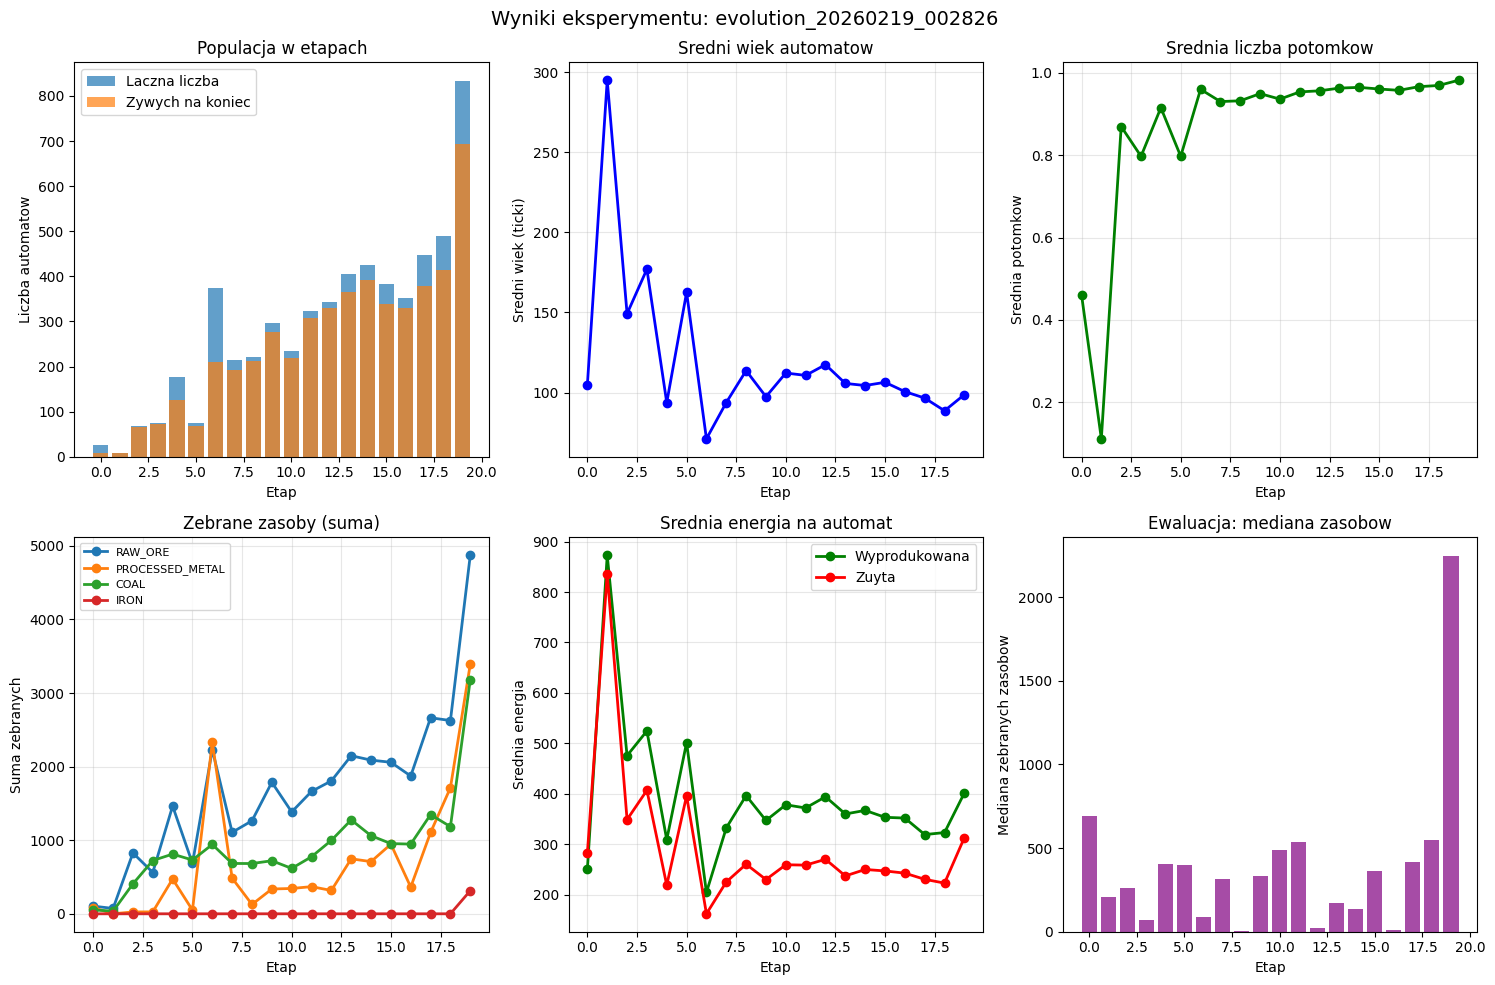


Wykres zapisany: results-test/evolution_20260219_002826/experiment_summary.png


In [39]:
if not all_stage_stats:
    print("Brak danych - najpierw uruchom eksperyment")
else:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Wyniki eksperymentu: {EXPERIMENT_NAME}', fontsize=14)
    
    stages = list(range(len(all_stage_stats)))
    
    # 1. Populacja
    ax = axes[0, 0]
    totals = [s['total_automata'] for s in all_stage_stats]
    alive = [s['alive_at_end'] for s in all_stage_stats]
    ax.bar(stages, totals, alpha=0.7, label='Laczna liczba')
    ax.bar(stages, alive, alpha=0.7, label='Zywych na koniec')
    ax.set_xlabel('Etap')
    ax.set_ylabel('Liczba automatow')
    ax.set_title('Populacja w etapach')
    ax.legend()
    
    # 2. Sredni wiek
    ax = axes[0, 1]
    avg_ages = [s['avg_age'] for s in all_stage_stats]
    ax.plot(stages, avg_ages, 'b-o', linewidth=2)
    ax.set_xlabel('Etap')
    ax.set_ylabel('Sredni wiek (ticki)')
    ax.set_title('Sredni wiek automatow')
    ax.grid(True, alpha=0.3)
    
    # 3. Srednia potomkow
    ax = axes[0, 2]
    avg_offspring = [s['avg_offspring'] for s in all_stage_stats]
    ax.plot(stages, avg_offspring, 'g-o', linewidth=2)
    ax.set_xlabel('Etap')
    ax.set_ylabel('Srednia potomkow')
    ax.set_title('Srednia liczba potomkow')
    ax.grid(True, alpha=0.3)
    
    # 4. Zasoby
    ax = axes[1, 0]
    if all_stage_stats[0]['resources']:
        resource_names = list(all_stage_stats[0]['resources'].keys())
        for res in resource_names:
            sums = [s['resources'].get(res, {}).get('sum', 0) for s in all_stage_stats]
            if sum(sums) > 0:
                ax.plot(stages, sums, '-o', label=res, linewidth=2)
        ax.legend(fontsize=8)
    ax.set_xlabel('Etap')
    ax.set_ylabel('Suma zebranych')
    ax.set_title('Zebrane zasoby (suma)')
    ax.grid(True, alpha=0.3)
    
    # 5. Energia
    ax = axes[1, 1]
    produced = [s['avg_energy_produced'] for s in all_stage_stats]
    consumed = [s['avg_energy_consumed'] for s in all_stage_stats]
    ax.plot(stages, produced, 'g-o', label='Wyprodukowana', linewidth=2)
    ax.plot(stages, consumed, 'r-o', label='Zuyta', linewidth=2)
    ax.set_xlabel('Etap')
    ax.set_ylabel('Srednia energia')
    ax.set_title('Srednia energia na automat')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Ewaluacja
    ax = axes[1, 2]
    if all_eval_results:
        eval_df = pd.DataFrame(all_eval_results)
        median_by_stage = eval_df.groupby('stage')['total_resources'].median()
        ax.bar(median_by_stage.index, median_by_stage.values, alpha=0.7, color='purple')
        ax.set_xlabel('Etap')
        ax.set_ylabel('Mediana zebranych zasobow')
        ax.set_title('Ewaluacja: mediana zasobow')
    else:
        ax.text(0.5, 0.5, 'Brak danych ewaluacji', ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'experiment_summary.png', dpi=150)
    plt.show()
    
    print(f"\nWykres zapisany: {RESULTS_DIR / 'experiment_summary.png'}")

### Historia populacji w czasie

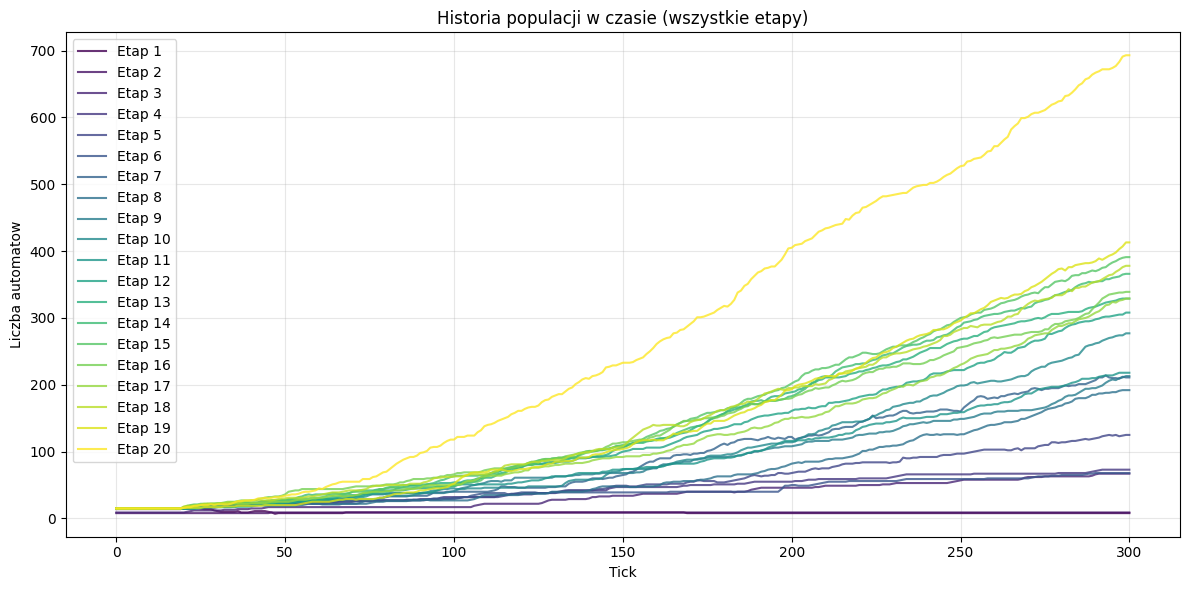

Wykres zapisany: results-test/evolution_20260219_002826/population_history.png


In [40]:
if population_histories:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(population_histories)))
    
    for i, history in enumerate(population_histories):
        ticks = list(range(len(history)))
        ax.plot(ticks, history, color=colors[i], label=f'Etap {i+1}', alpha=0.8, linewidth=1.5)
    
    ax.set_xlabel('Tick')
    ax.set_ylabel('Liczba automatow')
    ax.set_title('Historia populacji w czasie (wszystkie etapy)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'population_history.png', dpi=150)
    plt.show()
    
    print(f"Wykres zapisany: {RESULTS_DIR / 'population_history.png'}")
else:
    print("Brak danych - najpierw uruchom eksperyment")

### Podsumowanie tekstowe

In [41]:
if all_stage_stats:
    print("\n" + "="*60)
    print("PODSUMOWANIE EKSPERYMENTU")
    print("="*60)
    
    print(f"\nNazwa: {EXPERIMENT_NAME}")
    print(f"Liczba etapow: {len(all_stage_stats)}")
    print(f"Czas etapu: {STAGE_PARAMS['time']} tickow")
    print(f"Wspolczynnik mutacji: {STAGE_PARAMS['mutation_speed']}")
    
    first = all_stage_stats[0]
    last = all_stage_stats[-1]
    
    print(f"\n--- Porownanie etapu 1 vs {len(all_stage_stats)} ---")
    print(f"Laczna liczba automatow: {first['total_automata']} -> {last['total_automata']}")
    print(f"Sredni wiek: {first['avg_age']:.1f} -> {last['avg_age']:.1f}")
    print(f"Srednia potomkow: {first['avg_offspring']:.2f} -> {last['avg_offspring']:.2f}")
    
    if first['resources']:
        print(f"\n--- Zebrane zasoby (suma) ---")
        for res in first['resources'].keys():
            first_sum = first['resources'].get(res, {}).get('sum', 0)
            last_sum = last['resources'].get(res, {}).get('sum', 0)
            if first_sum > 0 or last_sum > 0:
                change = ((last_sum - first_sum) / max(first_sum, 1)) * 100 if first_sum > 0 else 0
                print(f"  {res}: {first_sum} -> {last_sum} ({change:+.1f}%)")
    
    if all_eval_results:
        eval_df = pd.DataFrame(all_eval_results)
        print(f"\n--- Wyniki ewaluacji (mediana zasobow) ---")
        for stage in sorted(eval_df['stage'].unique()):
            stage_evals = eval_df[eval_df['stage'] == stage]
            median_res = stage_evals['total_resources'].median()
            print(f"  Etap {stage + 1}: {median_res:.1f}")
    
    with open(RESULTS_DIR / 'summary.txt', 'w') as f:
        f.write(f"EKSPERYMENT: {EXPERIMENT_NAME}\n")
        f.write(f"Etapy: {len(all_stage_stats)}\n")
        f.write(f"Czas etapu: {STAGE_PARAMS['time']}\n")
        f.write(f"Mutacja: {STAGE_PARAMS['mutation_speed']}\n\n")
        
        for i, stats in enumerate(all_stage_stats):
            f.write(f"\n=== ETAP {i+1} ===\n")
            f.write(f"Automaty: {stats['total_automata']} (zywych: {stats['alive_at_end']})\n")
            f.write(f"Sredni wiek: {stats['avg_age']:.1f}\n")
            f.write(f"Srednia potomkow: {stats['avg_offspring']:.2f}\n")
    
    print(f"\nPodsumowanie zapisane: {RESULTS_DIR / 'summary.txt'}")
else:
    print("Brak danych - najpierw uruchom eksperyment")


PODSUMOWANIE EKSPERYMENTU

Nazwa: evolution_20260219_002826
Liczba etapow: 20
Czas etapu: 300 tickow
Wspolczynnik mutacji: 0.03

--- Porownanie etapu 1 vs 20 ---
Laczna liczba automatow: 26 -> 833
Sredni wiek: 104.9 -> 98.8
Srednia potomkow: 0.46 -> 0.98

--- Zebrane zasoby (suma) ---
  RAW_ORE: 104 -> 4872 (+4584.6%)
  PROCESSED_METAL: 85 -> 3392 (+3890.6%)
  COAL: 53 -> 3181 (+5901.9%)
  IRON: 0 -> 314 (+0.0%)

--- Wyniki ewaluacji (mediana zasobow) ---
  Etap 1: 694.0
  Etap 2: 210.0
  Etap 3: 261.0
  Etap 4: 71.0
  Etap 5: 407.0
  Etap 6: 399.0
  Etap 7: 88.0
  Etap 8: 314.0
  Etap 9: 5.0
  Etap 10: 335.0
  Etap 11: 489.0
  Etap 12: 535.0
  Etap 13: 25.0
  Etap 14: 174.0
  Etap 15: 135.0
  Etap 16: 361.0
  Etap 17: 12.0
  Etap 18: 415.0
  Etap 19: 546.1
  Etap 20: 2245.7

Podsumowanie zapisane: results-test/evolution_20260219_002826/summary.txt
